Maximum independent set (S): [1, 4, 6, 11]


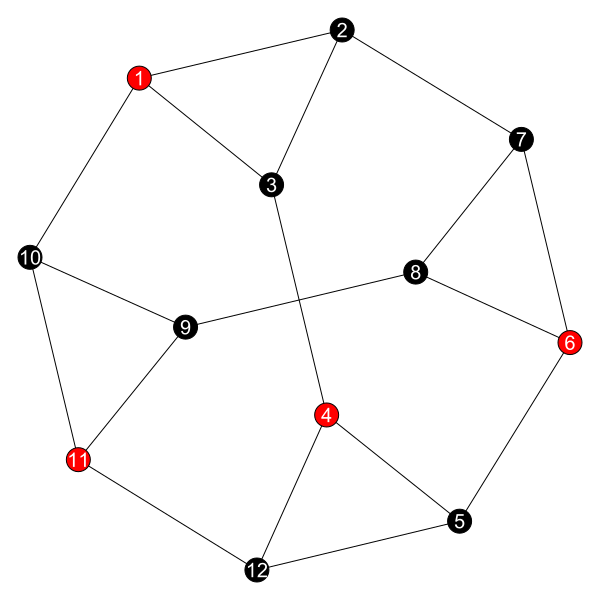

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 5 – Graph problems
#  Section: 5.2 – Maximum Independent Set Problem (MISP)
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP    # Modeling language
using HiGHS   # Solver
using Graphs  # Graphs package
using Karnak  # Graphs Visualization package
using Colors  # Colors package

# Function to plot the solution
function plot_solution(graph, S)
    # Create color vector
    n = Graphs.nv(graph)
    vertexfillcolors = [i in S ? Colors.RGB(1,0,0) : Colors.RGB(0,0,0) for i in 1:n]

    # Draw graph
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(20)
        drawgraph(
            graph,
            layout = stress,
            vertexshapesizes = 12,
            vertexlabels = 1:n,
            vertexfillcolors = vertexfillcolors
        )
    end
end

# Function to solve the Maximum Independent Set Problem (MISP)
function solve_misp(graph)
    # Total of vertices
    n = Graphs.nv(graph)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n], Bin)

    # Objective function: maximize the total of selected vertices
    @objective(model, Max, sum(x))

    # Independence constraint
    @constraint(model, [i = 1:n, j = 1:n; Graphs.has_edge(graph, i, j)], x[i] + x[j] <= 1)

    # Run the solver
    JuMP.optimize!(model)

    # Independent set S
    S = findall(JuMP.value.(x) .>= 0.5)

    # Print solution
    println("Maximum independent set (S): $S")

    # Plot solution
    plot_solution(graph, S)
end

# Create graph
graph = Karnak.smallgraph("truncatedtetrahedron")

# Solve the Maximum Independent Set Problem
solve_misp(graph)